In [1]:
# ============================================
# TASK 2: DATA INGESTION USING PANDAS
# Dataset: netflix_titles.csv
# ============================================

# Import Pandas
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv("netflix_titles.csv.xls")

# ============================================
# 1. Display Dataset Overview
# ============================================

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print("\nFirst 5 Rows of the Dataset:")
print(df.head())

# ============================================
# 2. Analyze Shape
# ============================================

print("\n" + "=" * 50)
print("DATASET SHAPE")
print("=" * 50)

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("Shape of Dataset:", df.shape)

# ============================================
# 3. Display Column Names
# ============================================

print("\n" + "=" * 50)
print("COLUMN NAMES")
print("=" * 50)

print(df.columns.tolist())

# ============================================
# 4. Data Types Analysis
# ============================================

print("\n" + "=" * 50)
print("DATA TYPES")
print("=" * 50)

print(df.dtypes)

# ============================================
# 5. Missing Values Analysis
# ============================================

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)

print(df.isnull().sum())

# ============================================
# 6. Duplicate Records Analysis
# ============================================

print("\n" + "=" * 50)
print("DUPLICATE RECORDS")
print("=" * 50)

duplicate_count = df.duplicated().sum()
print("Number of Duplicate Records:", duplicate_count)

# ============================================
# 7. Dataset Information
# ============================================

print("\n" + "=" * 50)
print("DATASET INFORMATION")
print("=" * 50)

df.info()

DATASET OVERVIEW

First 5 Rows of the Dataset:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV

In [2]:
# ============================================
# TASK 3: DATA CLEANING AND PREPROCESSING
# ============================================

import pandas as pd

# Load dataset
df = pd.read_csv("netflix_titles.csv.xls")

print("Original Shape:", df.shape)

# ============================================
# 1. Check Missing Values
# ============================================

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# ============================================
# 2. Handle Missing Values
# ============================================

# Fill missing values with suitable defaults

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')
df['duration'] = df['duration'].fillna('Unknown')

# Drop rows where important columns are missing
df.dropna(subset=['date_added'], inplace=True)

# ============================================
# 3. Remove Duplicate Records
# ============================================

duplicates_before = df.duplicated().sum()
print("\nDuplicate Records Before Removal:", duplicates_before)

df.drop_duplicates(inplace=True)

duplicates_after = df.duplicated().sum()
print("Duplicate Records After Removal:", duplicates_after)

# ============================================
# 4. Correct Data Types
# ============================================

# Convert date_added to datetime format, using 'mixed' format inference
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

# Convert release_year to integer
df['release_year'] = df['release_year'].astype(int)

# ============================================
# 5. Rename Columns for Clarity
# ============================================

df.rename(columns={
    'show_id': 'Show_ID',
    'type': 'Content_Type',
    'title': 'Title',
    'country': 'Country',
    'release_year': 'Release_Year',
    'date_added': 'Date_Added',
    'listed_in': 'Genre'
}, inplace=True)

# ============================================
# 6. Verify Cleaning Results
# ============================================

print("\nDataset Shape After Cleaning:", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nUpdated Data Types:")
print(df.dtypes)

# ============================================
# 7. Save Cleaned Dataset
# ============================================

df.to_csv("netflix_titles_cleaned.csv", index=False)

print("\nCleaned dataset saved as 'netflix_titles_cleaned.csv'")

# Display sample records
print("\nFirst 5 Rows of Cleaned Dataset:")
print(df.head())

Original Shape: (8807, 12)

Missing Values Before Cleaning:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Records Before Removal: 0
Duplicate Records After Removal: 0

Dataset Shape After Cleaning: (8797, 12)

Missing Values After Cleaning:
Show_ID         0
Content_Type    0
Title           0
director        0
cast            0
Country         0
Date_Added      0
Release_Year    0
rating          0
duration        0
Genre           0
description     0
dtype: int64

Updated Data Types:
Show_ID                 object
Content_Type            object
Title                   object
director                object
cast                    object
Country                 object
Date_Added      datetime64[ns]
Release_Year             int64
rating                  object


In [3]:
# ============================================
# TASK 4: SQLITE DATABASE INTEGRATION
# ============================================

import pandas as pd
import sqlite3

# ============================================
# 1. Load Cleaned Dataset
# ============================================

df = pd.read_csv("netflix_titles_cleaned.csv")

print("Dataset Loaded Successfully")
print("Number of Records:", len(df))

# ============================================
# 2. Create SQLite Database
# ============================================

conn = sqlite3.connect("netflix.db")

print("\nSQLite Database Created Successfully")

# ============================================
# 3. Load Dataset into Database
# ============================================

df.to_sql(
    name="netflix_titles",
    con=conn,
    if_exists="replace",
    index=False
)

print("Dataset Loaded into Database Successfully")

# ============================================
# 4. Verify Table Creation
# ============================================

cursor = conn.cursor()

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table';
""")

tables = cursor.fetchall()

print("\nTables in Database:")
for table in tables:
    print(table[0])

# ============================================
# 5. Verify Record Insertion
# ============================================

cursor.execute("""
SELECT COUNT(*)
FROM netflix_titles;
""")

record_count = cursor.fetchone()[0]

print("\nTotal Records Inserted:", record_count)

# ============================================
# 6. Display Sample Records
# ============================================

sample_data = pd.read_sql_query(
    "SELECT * FROM netflix_titles LIMIT 5",
    conn
)

print("\nFirst 5 Records:")
print(sample_data)

# ============================================
# 7. Close Connection
# ============================================

conn.close()

print("\nDatabase Connection Closed")

Dataset Loaded Successfully
Number of Records: 8797

SQLite Database Created Successfully
Dataset Loaded into Database Successfully

Tables in Database:
netflix_titles

Total Records Inserted: 8797

First 5 Records:
  Show_ID Content_Type                  Title         director  \
0      s1        Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2      TV Show          Blood & Water          Unknown   
2      s3      TV Show              Ganglands  Julien Leclercq   
3      s4      TV Show  Jailbirds New Orleans          Unknown   
4      s5      TV Show           Kota Factory          Unknown   

                                                cast        Country  \
0                                      Not Available  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                      Not Available        Unknown   
4  Mayur More, Jitendra Kumar, R

In [4]:
# ============================================
# TASK 5: SQL ANALYSIS
# ============================================

import pandas as pd
import sqlite3

# Connect to SQLite Database
conn = sqlite3.connect("netflix.db")

# ============================================
# 1. FILTERING QUERY
# ============================================

print("="*60)
print("1. FILTERING QUERY")
print("="*60)

query1 = """
SELECT Title, Country, Release_Year
FROM netflix_titles
WHERE Country = 'India';
"""

result1 = pd.read_sql_query(query1, conn)
print(result1.head(10))

# ============================================
# 2. SORTING QUERY
# ============================================

print("\n" + "="*60)
print("2. SORTING QUERY")
print("="*60)

query2 = """
SELECT Title, Release_Year
FROM netflix_titles
ORDER BY Release_Year DESC;
"""

result2 = pd.read_sql_query(query2, conn)
print(result2.head(10))

# ============================================
# 3. AGGREGATION QUERY
# ============================================

print("\n" + "="*60)
print("3. AGGREGATION QUERY")
print("="*60)

query3 = """
SELECT COUNT(*) AS Total_Content
FROM netflix_titles;
"""

result3 = pd.read_sql_query(query3, conn)
print(result3)

# ============================================
# 4. GROUP BY QUERY
# ============================================

print("\n" + "="*60)
print("4. GROUP BY QUERY")
print("="*60)

query4 = """
SELECT Content_Type, COUNT(*) AS Total_Count
FROM netflix_titles
GROUP BY Content_Type;
"""

result4 = pd.read_sql_query(query4, conn)
print(result4)

# ============================================
# 5. CONDITIONAL QUERY
# ============================================

print("\n" + "="*60)
print("5. CONDITIONAL QUERY")
print("="*60)

query5 = """
SELECT Title,
       Release_Year,
       CASE
           WHEN Release_Year >= 2020 THEN 'Recent'
           ELSE 'Old'
       END AS Category
FROM netflix_titles
LIMIT 10;
"""

result5 = pd.read_sql_query(query5, conn)
print(result5)

# Close Connection
conn.close()

1. FILTERING QUERY
                            Title Country  Release_Year
0                    Kota Factory   India          2021
1                           Jeans   India          1998
2                    Chhota Bheem   India          2021
3                   Dharmakshetra   India          2014
4   Raja Rasoi Aur Anya Kahaniyan   India          2014
5  Stories by Rabindranath Tagore   India          2015
6                Angamaly Diaries   India          2017
7                          Anjaam   India          1994
8                          Dhanak   India          2015
9                         Gurgaon   India          2017

2. SORTING QUERY
                                 Title  Release_Year
0                        Blood & Water          2021
1                            Ganglands          2021
2                Jailbirds New Orleans          2021
3                         Kota Factory          2021
4                        Midnight Mass          2021
5     My Little Pony: A New G

In [5]:
# ============================================
# TASK 6: SQL-BASED DATA TRANSFORMATION
# ============================================

import pandas as pd
import sqlite3

# Connect to SQLite Database
conn = sqlite3.connect("netflix.db")

# ============================================
# Create Derived Columns Using SQL
# ============================================

query = """
SELECT *,

       CASE
           WHEN Release_Year >= 2020 THEN 'Recent'
           WHEN Release_Year >= 2010 THEN 'Modern'
           ELSE 'Classic'
       END AS Content_Age,

       CASE
           WHEN Content_Type = 'Movie' THEN 'Film Content'
           ELSE 'Series Content'
       END AS Content_Category

FROM netflix_titles;
"""

# Execute Query
transformed_df = pd.read_sql_query(query, conn)

# ============================================
# Display Transformed Dataset
# ============================================

print("First 10 Records of Transformed Dataset:")
print(transformed_df.head(10))

# ============================================
# Export to CSV
# ============================================

transformed_df.to_csv(
    "netflix_titles_transformed.csv",
    index=False
)

print("\nTransformed dataset exported successfully!")
print("File Name: netflix_titles_transformed.csv")

# Close Database Connection
conn.close()

First 10 Records of Transformed Dataset:
  Show_ID Content_Type                             Title  \
0      s1        Movie              Dick Johnson Is Dead   
1      s2      TV Show                     Blood & Water   
2      s3      TV Show                         Ganglands   
3      s4      TV Show             Jailbirds New Orleans   
4      s5      TV Show                      Kota Factory   
5      s6      TV Show                     Midnight Mass   
6      s7        Movie  My Little Pony: A New Generation   
7      s8        Movie                           Sankofa   
8      s9      TV Show     The Great British Baking Show   
9     s10        Movie                      The Starling   

                        director  \
0                Kirsten Johnson   
1                        Unknown   
2                Julien Leclercq   
3                        Unknown   
4                        Unknown   
5                  Mike Flanagan   
6  Robert Cullen, José Luis Ucha   
7         

In [6]:
# ============================================
# TASK 7: ETL PIPELINE
# ============================================

import pandas as pd

# ============================================
# EXTRACT STAGE
# ============================================

print("=" * 50)
print("EXTRACT STAGE")
print("=" * 50)

# Read source file
df = pd.read_csv("netflix_titles.csv.xls")

print("Data extracted successfully.")
print("Original Shape:", df.shape)

# ============================================
# TRANSFORM STAGE
# ============================================

print("\n" + "=" * 50)
print("TRANSFORM STAGE")
print("=" * 50)

# Handle missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')
df['duration'] = df['duration'].fillna('Unknown')

# Remove rows with missing date_added
df.dropna(subset=['date_added'], inplace=True)

# Remove duplicate records
df.drop_duplicates(inplace=True)

# Convert data types
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

# Rename columns
df.rename(columns={
    'show_id': 'Show_ID',
    'type': 'Content_Type',
    'title': 'Title',
    'release_year': 'Release_Year',
    'date_added': 'Date_Added',
    'listed_in': 'Genre'
}, inplace=True)

# Create derived columns
df['Content_Age'] = df['Release_Year'].apply(
    lambda x: 'Recent' if x >= 2020
    else 'Modern' if x >= 2010
    else 'Classic'
)

df['Content_Category'] = df['Content_Type'].apply(
    lambda x: 'Film Content' if x == 'Movie'
    else 'Series Content'
)

print("Data transformed successfully.")
print("Transformed Shape:", df.shape)

# ============================================
# LOAD STAGE
# ============================================

print("\n" + "=" * 50)
print("LOAD STAGE")
print("=" * 50)

# Save processed data
df.to_csv("netflix_etl_output.csv", index=False)

print("Processed data loaded successfully.")
print("Output File: netflix_etl_output.csv")

# Display sample data
print("\nFirst 5 Rows:")
print(df.head())

EXTRACT STAGE
Data extracted successfully.
Original Shape: (8807, 12)

TRANSFORM STAGE
Data transformed successfully.
Transformed Shape: (8797, 14)

LOAD STAGE
Processed data loaded successfully.
Output File: netflix_etl_output.csv

First 5 Rows:
  Show_ID Content_Type                  Title         director  \
0      s1        Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2      TV Show          Blood & Water          Unknown   
2      s3      TV Show              Ganglands  Julien Leclercq   
3      s4      TV Show  Jailbirds New Orleans          Unknown   
4      s5      TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                      Not Available  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                      Not Available        Unknown   
4

In [7]:
# ==========================================================
# TASK 8: PYSPARK MEDALLION ARCHITECTURE
# Dataset: Netflix Titles
# ==========================================================

# Install PySpark (Run only once if not installed)
# !pip install pyspark

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count

# ==========================================================
# CREATE SPARK SESSION
# ==========================================================

spark = SparkSession.builder \
    .appName("Netflix_Medallion_Architecture") \
    .getOrCreate()

print("=" * 60)
print("SPARK SESSION CREATED SUCCESSFULLY")
print("=" * 60)

# ==========================================================
# BRONZE LAYER
# RAW DATA INGESTION
# ==========================================================

print("\n" + "=" * 60)
print("BRONZE LAYER")
print("=" * 60)

# Read Raw CSV Dataset
bronze_df = spark.read.csv(
    "netflix_titles.csv.xls", # Corrected file name here
    header=True,
    inferSchema=True
)

print("Bronze Layer Record Count:", bronze_df.count())

# Display Sample Data
print("\nBronze Layer Sample Data:")
bronze_df.show(5)

# Save Bronze Layer as Parquet
bronze_df.write.mode("overwrite").parquet("bronze_netflix")

print("\nBronze Layer Saved Successfully")
print("Location: bronze_netflix/")

# ==========================================================
# SILVER LAYER
# DATA CLEANING AND STANDARDIZATION
# ==========================================================

print("\n" + "=" * 60)
print("SILVER LAYER")
print("=" * 60)

silver_df = bronze_df

# Remove Null Records from Important Columns
silver_df = silver_df.na.drop(
    subset=[
        "title",
        "type",
        "release_year"
    ]
)

# Remove Duplicate Records
silver_df = silver_df.dropDuplicates()

# Standardize Country Column
silver_df = silver_df.fillna({
    "country": "Unknown"
})

print("Silver Layer Record Count:", silver_df.count())

print("\nSilver Layer Sample Data:")
silver_df.show(5)

# Save Silver Layer as Parquet
silver_df.write.mode("overwrite").parquet("silver_netflix")

print("\nSilver Layer Saved Successfully")
print("Location: silver_netflix/")

# ==========================================================
# GOLD LAYER
# BUSINESS READY DATASET
# KPI GENERATION
# ==========================================================

print("\n" + "=" * 60)
print("GOLD LAYER")
print("=" * 60)

# KPI 1 - Count of Movies and TV Shows

gold_df = silver_df.groupBy("type") \
                   .agg(
                       count("*").alias("Total_Content")
                   )

print("Gold Layer KPI Data:")
gold_df.show()

# Save Gold Layer as Parquet
gold_df.write.mode("overwrite").parquet("gold_netflix")

print("\nGold Layer Saved Successfully")
print("Location: gold_netflix/")

# ==========================================================
# VERIFY BRONZE LAYER
# ==========================================================

print("\n" + "=" * 60)
print("VERIFY BRONZE LAYER")
print("=" * 60)

bronze_verify = spark.read.parquet("bronze_netflix")

print("Bronze Records:", bronze_verify.count())
bronze_verify.show(5)

# ==========================================================
# VERIFY SILVER LAYER
# ==========================================================

print("\n" + "=" * 60)
print("VERIFY SILVER LAYER")
print("=" * 60)

silver_verify = spark.read.parquet("silver_netflix")

print("Silver Records:", silver_verify.count())
silver_verify.show(5)

# ==========================================================
# VERIFY GOLD LAYER
# ==========================================================

print("\n" + "=" * 60)
print("VERIFY GOLD LAYER")
print("=" * 60)

gold_verify = spark.read.parquet("gold_netflix")

gold_verify.show()

# ==========================================================
# DISPLAY SCHEMA OF ALL LAYERS
# ==========================================================

print("\n" + "=" * 60)
print("BRONZE SCHEMA")
print("=" * 60)
bronze_verify.printSchema()

print("\n" + "=" * 60)
print("SILVER SCHEMA")
print("=" * 60)
silver_verify.printSchema()

print("\n" + "=" * 60)
print("GOLD SCHEMA")
print("=" * 60)
gold_verify.printSchema()

# ==========================================================
# STOP SPARK SESSION
# ==========================================================

spark.stop()

print("\n" + "=" * 60)
print("MEDALLION ARCHITECTURE IMPLEMENTED SUCCESSFULLY")
print("=" * 60)

print("""
Generated Parquet Layers:

1. bronze_netflix/
   - Raw Netflix data

2. silver_netflix/
   - Cleaned and standardized Netflix data

3. gold_netflix/
   - Business-ready KPI dataset

All layers are stored in Parquet format.
""")

SPARK SESSION CREATED SUCCESSFULLY

BRONZE LAYER
Bronze Layer Record Count: 8809

Bronze Layer Sample Data:
+-------+-------+--------------------+---------------+--------------------+-------------+------------------+------------+------+---------+--------------------+--------------------+
|show_id|   type|               title|       director|                cast|      country|        date_added|release_year|rating| duration|           listed_in|         description|
+-------+-------+--------------------+---------------+--------------------+-------------+------------------+------------+------+---------+--------------------+--------------------+
|     s1|  Movie|Dick Johnson Is Dead|Kirsten Johnson|                NULL|United States|September 25, 2021|        2020| PG-13|   90 min|       Documentaries|As her father nea...|
|     s2|TV Show|       Blood & Water|           NULL|Ama Qamata, Khosi...| South Africa|September 24, 2021|        2021| TV-MA|2 Seasons|International TV ...|After cro

In [8]:
# ==========================================================
# TASK 9: CSV vs PARQUET COMPARISON
# ==========================================================

import pandas as pd
from IPython.display import display

# ==========================================================
# CREATE COMPARISON TABLE
# ==========================================================

comparison_data = {
    "Feature": [
        "File Size",
        "Storage Efficiency",
        "Read Performance",
        "Write Performance",
        "Advantages",
        "Limitations"
    ],

    "CSV": [
        "Larger",
        "Lower",
        "Slower for large datasets",
        "Fast",
        "Easy to read, edit and share",
        "Consumes more storage space"
    ],

    "Parquet": [
        "Smaller",
        "Higher",
        "Faster due to columnar storage",
        "Moderate",
        "Compressed, efficient and optimized for analytics",
        "Not human-readable"
    ]
}

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)

# ==========================================================
# DISPLAY COMPARISON TABLE
# ==========================================================

print("=" * 70)
print("CSV VS PARQUET COMPARISON")
print("=" * 70)

display(comparison_df)

CSV VS PARQUET COMPARISON


,Feature,CSV,Parquet
0,File Size,Larger,Smaller
1,Storage Efficiency,Lower,Higher
2,Read Performance,Slower for large datasets,Faster due to columnar storage
3,Write Performance,Fast,Moderate
4,Advantages,"Easy to read, edit and share","Compressed, efficient and optimized for analytics"
5,Limitations,Consumes more storage space,Not human-readable


In [9]:
# ==========================================================
# TASK 10: PARQUET TO PANDAS CONVERSION
# ==========================================================

from pyspark.sql import SparkSession
import pandas as pd

# Create Spark Session
spark = SparkSession.builder \
    .appName("Parquet_To_Pandas") \
    .getOrCreate()

# ==========================================================
# READ PARQUET FILE USING PYSPARK
# ==========================================================

parquet_df = spark.read.parquet("silver_netflix")

print("=" * 60)
print("PARQUET FILE READ SUCCESSFULLY")
print("=" * 60)

print("\nParquet Data Sample:")
parquet_df.show(5)

# ==========================================================
# CONVERT PYSPARK DATAFRAME TO PANDAS DATAFRAME
# ==========================================================

pandas_df = parquet_df.toPandas()

print("\nConversion to Pandas DataFrame Successful")

# ==========================================================
# DISPLAY PANDAS DATAFRAME
# ==========================================================

print("\nFirst 5 Rows:")
print(pandas_df.head())

# ==========================================================
# VALIDATE THE RESULTS
# ==========================================================

print("\nDataset Shape:")
print(pandas_df.shape)

print("\nColumn Names:")
print(list(pandas_df.columns))

print("\nData Types:")
print(pandas_df.dtypes)

# ==========================================================
# STOP SPARK SESSION
# ==========================================================

spark.stop()

PARQUET FILE READ SUCCESSFULLY

Parquet Data Sample:
+-------+-----+--------------------+--------------------+--------------------+--------------------+--------------+------------+------+--------+--------------------+--------------------+
|show_id| type|               title|            director|                cast|             country|    date_added|release_year|rating|duration|           listed_in|         description|
+-------+-----+--------------------+--------------------+--------------------+--------------------+--------------+------------+------+--------+--------------------+--------------------+
|   s461|Movie|           Surf's Up|Ash Brannon, Chri...|Shia LaBeouf, Jef...|United States, Ca...| July 15, 2021|        2007|    PG|  86 min|Children & Family...|This Oscar-nomina...|
|   s695|Movie|               Aziza|      Soudade Kaadan|Caress Bashar, Ab...|      Lebanon, Syria| June 17, 2021|        2019| TV-PG|  13 min|Comedies, Dramas,...|This short film f...|
|   s883|Movie|Ju

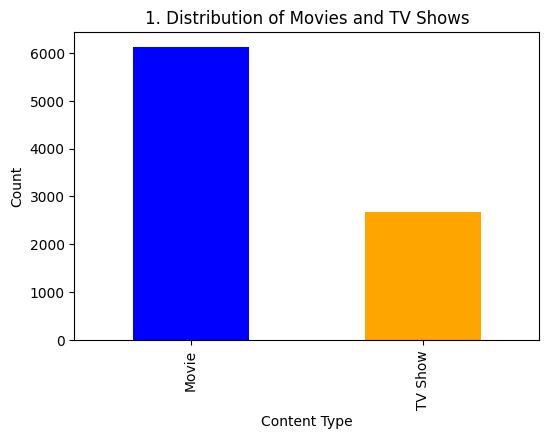

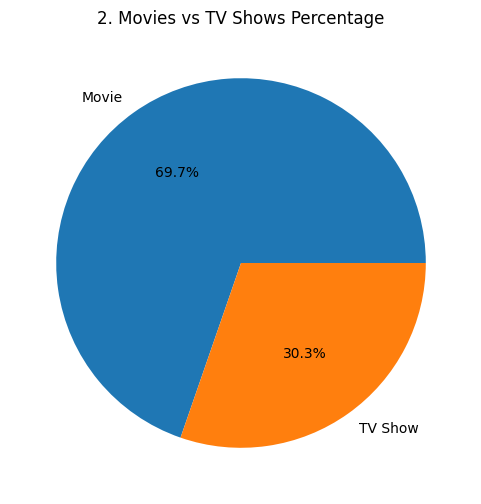

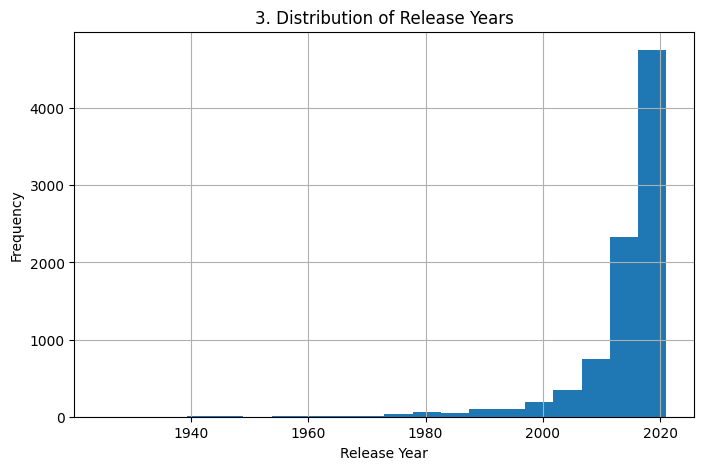

In [10]:
# ==========================================================
# TASK 11: DATA VISUALIZATION
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Load Cleaned Dataset
df = pd.read_csv("netflix_titles_cleaned.csv")

# ==========================================================
# VISUALIZATION 1 - BAR CHART
# Content Type Distribution
# ==========================================================

content_counts = df['Content_Type'].value_counts()

plt.figure(figsize=(6,4))

content_counts.plot(
    kind='bar',
    color=['blue', 'orange']   # Movies = Blue, TV Shows = Orange
)

plt.title('1. Distribution of Movies and TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

# ==========================================================
# VISUALIZATION 2 - PIE CHART
# Movies vs TV Shows Percentage
# ==========================================================

plt.figure(figsize=(6,6))
content_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('2. Movies vs TV Shows Percentage')
plt.ylabel('')
plt.show()

# ==========================================================
# VISUALIZATION 3 - HISTOGRAM
# Release Year Distribution
# ==========================================================

plt.figure(figsize=(8,5))
df['Release_Year'].hist(bins=20)

plt.title('3. Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

In [11]:

# ==========================================================
# TASK 12: MACHINE LEARNING MODEL
# ==========================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================================
# LOAD PROCESSED DATASET
# ==========================================================

df = pd.read_csv("netflix_titles_cleaned.csv")

print("Dataset Shape:", df.shape)

# ==========================================================
# SELECT FEATURES AND TARGET COLUMN
# ==========================================================

# Target Column
target = "Content_Type"

# Select useful features
features = ["Release_Year"]

X = df[features]
y = df[target]

# ==========================================================
# ENCODE TARGET VARIABLE
# ==========================================================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# ==========================================================
# SPLIT DATA INTO TRAINING AND TESTING SETS
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Records:", len(X_train))
print("Testing Records :", len(X_test))

# ==========================================================
# TRAIN MACHINE LEARNING MODEL
# ==========================================================

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

print("\nModel Training Completed")

# ==========================================================
# MAKE PREDICTIONS
# ==========================================================

y_pred = model.predict(X_test)

# ==========================================================
# EVALUATE MODEL
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================================
# SAMPLE PREDICTIONS
# ==========================================================

sample_predictions = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(y_test[:10]),
    "Predicted": label_encoder.inverse_transform(y_pred[:10])
})

print("\nSample Predictions:")
print(sample_predictions)

Dataset Shape: (8797, 12)
Training Records: 7037
Testing Records : 1760

Model Training Completed

Accuracy Score:
0.7079545454545455

Confusion Matrix:
[[1169   60]
 [ 454   77]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.95      0.82      1229
           1       0.56      0.15      0.23       531

    accuracy                           0.71      1760
   macro avg       0.64      0.55      0.53      1760
weighted avg       0.67      0.71      0.64      1760


Sample Predictions:
    Actual Predicted
0  TV Show     Movie
1  TV Show     Movie
2  TV Show     Movie
3    Movie     Movie
4  TV Show     Movie
5  TV Show   TV Show
6    Movie     Movie
7    Movie     Movie
8    Movie   TV Show
9    Movie     Movie
